In [6]:
import pandas as pd
df=pd.read_excel("/content/nordic_churn_customers (3).xlsx")
df.head()

,CustomerID,Country,Age,Gender,SubscriptionPlan,MonthlySpend_SEK,TenureMonths,Churned
0,10001,Denmark,29,Female,Basic,242.34,1,0
1,10002,Finland,18,Female,Basic,467.16,5,0
2,10003,Sweden,30,Female,Basic,179.17,9,0
3,10004,Denmark,44,Female,Basic,413.66,44,0
4,10005,Denmark,40,Female,Family,241.26,20,0


***# Basic Data Inspection***

In [7]:
df.info()
df.describe()
df.isnull().sum()
df["Country"].value_counts()
df["Gender"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        10000 non-null  int64  
 1   Country           10000 non-null  object 
 2   Age               10000 non-null  int64  
 3   Gender            10000 non-null  object 
 4   SubscriptionPlan  10000 non-null  object 
 5   MonthlySpend_SEK  10000 non-null  float64
 6   TenureMonths      10000 non-null  int64  
 7   Churned           10000 non-null  int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 625.1+ KB


,count
Gender,
Male,5082
Female,4918


In [8]:
# Data Cleaning:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df

,CustomerID,Country,Age,Gender,SubscriptionPlan,MonthlySpend_SEK,TenureMonths,Churned
0,10001,Denmark,29,Female,Basic,242.34,1,0
1,10002,Finland,18,Female,Basic,467.16,5,0
2,10003,Sweden,30,Female,Basic,179.17,9,0
3,10004,Denmark,44,Female,Basic,413.66,44,0
4,10005,Denmark,40,Female,Family,241.26,20,0
...,...,...,...,...,...,...,...,...
9995,19996,Finland,27,Female,Basic,306.52,1,1
9996,19997,Denmark,47,Male,Basic,232.45,4,0
9997,19998,Norway,37,Male,Premium,188.41,14,1
9998,19999,Norway,41,Female,Basic,273.70,10,1


#Exploratory Data Analysis:
#Explore relationship between variables and churn ***bold text***

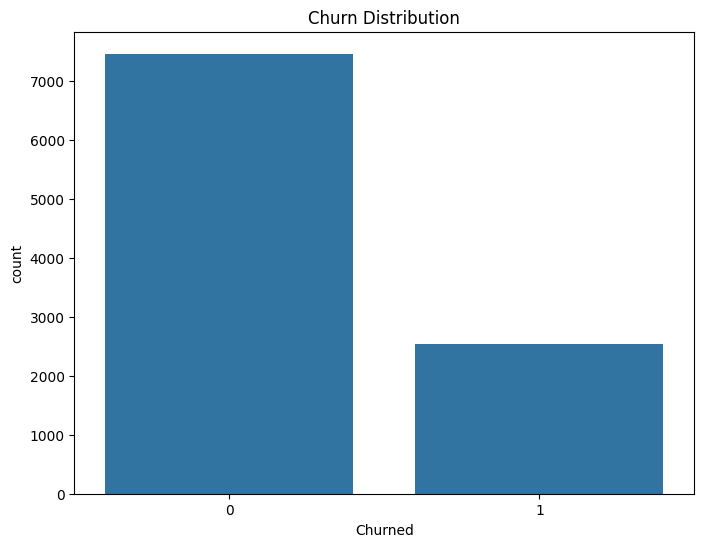

In [36]:
# Churn Distribution:
# Checking how many customers left vs stayed:
# 1=Left and 0=Stayed
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.countplot(x='Churned',data=df)
plt.title("Churn Distribution")
plt.savefig("churn_distribution.png",bbox_inches="tight")
plt.show()

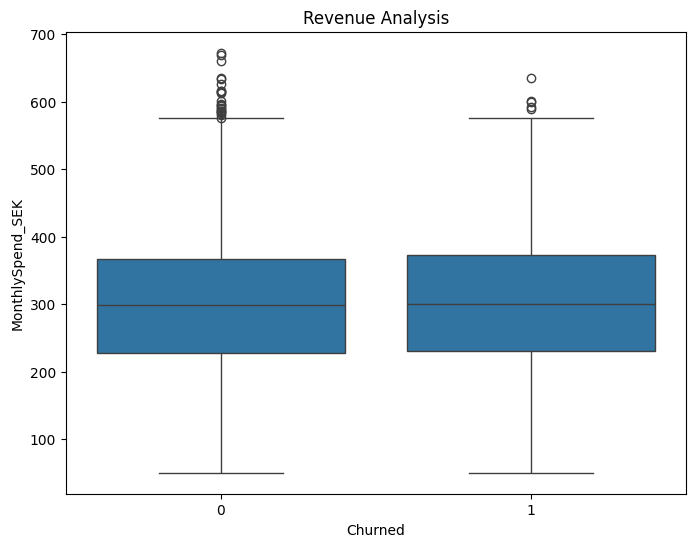

In [35]:
# Revenue Analysis:
# Creating boxplot:
# Check churned customers are spending less or more?
plt.figure(figsize=(8,6))
sns.boxplot(x='Churned',y='MonthlySpend_SEK',data=df)
plt.title("Revenue Analysis")
plt.savefig("revenue_analysis.png",bbox_inches="tight")
plt.show()

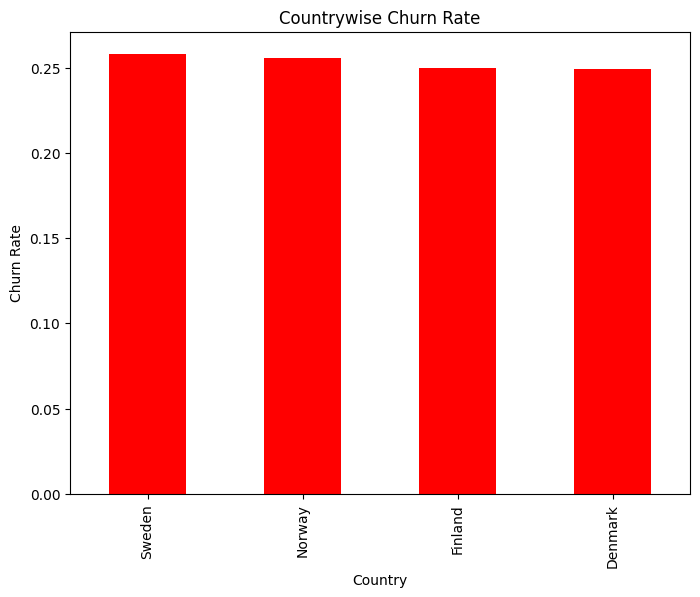

In [34]:
# Countrywise Churn rate:
# checking which country's customers churn more?
country_wise_churn_rate=df.groupby("Country")["Churned"].mean().sort_values(ascending=False)
country_wise_churn_rate.plot(kind="bar",figsize=(8,6),color="red")
plt.title("Countrywise Churn Rate")
plt.xlabel("Country")
plt.ylabel("Churn Rate")
plt.savefig("countrywise_churn_rate.png",bbox_inches="tight")
plt.show()

***Statistical Test:***

In [14]:
# T-test- Are Average monthly spends different for churned vs not churned?
from scipy.stats import ttest_ind
churned=df[df["Churned"]==1]["MonthlySpend_SEK"]
not_churned=df[df["Churned"]==0]["MonthlySpend_SEK"]
t_statistic,p_value=ttest_ind(churned,not_churned)
print("T-statistic:",t_statistic)
print("P-value:",p_value)

T-statistic: 1.2487912052093586
P-value: 0.2117706903643122


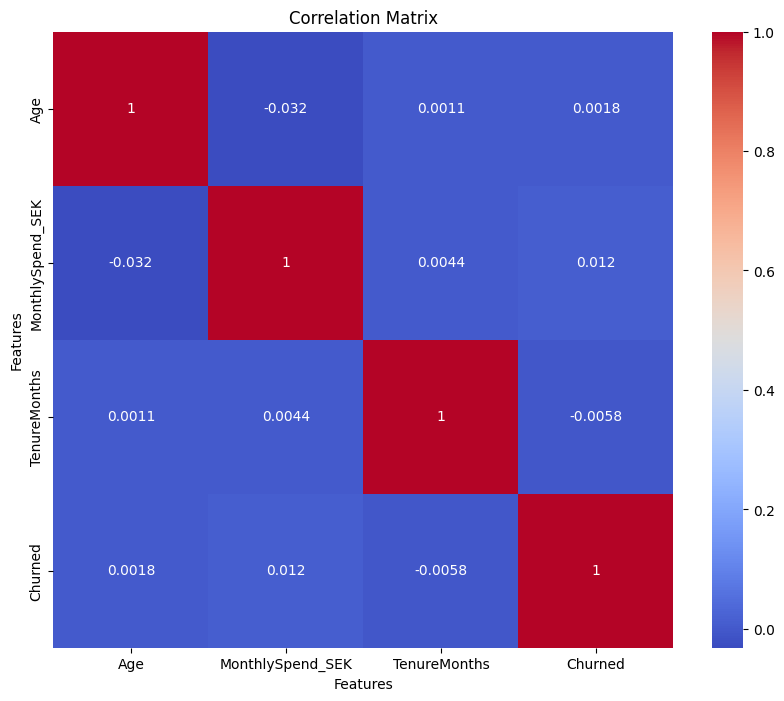

In [33]:
# Correlation Matrix:
# Finding which feature is strongly correlated with churn:
plt.figure(figsize=(10,8))
corr=df[['Age','MonthlySpend_SEK','TenureMonths','Churned']].corr()
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.xlabel("Features")
plt.ylabel("Features")
plt.savefig("correlation_matrix.png",bbox_inches="tight")
plt.show()

In [22]:
# Build Logistic Regression Model:
# Predicting probability of churn:
import statsmodels.api as sm
# Preparing Data
x=df[['Age','MonthlySpend_SEK','TenureMonths']]
x=sm.add_constant(x)
y=df['Churned']

# Building model
model=sm.Logit(y,x) # Creating logistic regression model
result=model.fit()  # Fits the model to the data

# Summary:
print(result.summary()) # Prints a summary of the model results,including coefficients,p-values, and other statistics.

Optimization terminated successfully.
         Current function value: 0.565942
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                Churned   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9996
Method:                           MLE   Df Model:                            3
Date:                Wed, 30 Apr 2025   Pseudo R-squ.:               0.0001719
Time:                        03:10:09   Log-Likelihood:                -5659.4
converged:                       True   LL-Null:                       -5660.4
Covariance Type:            nonrobust   LLR p-value:                    0.5837
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.1711      0.114    -10.253      0.000      -1.395      -0.947
Age        

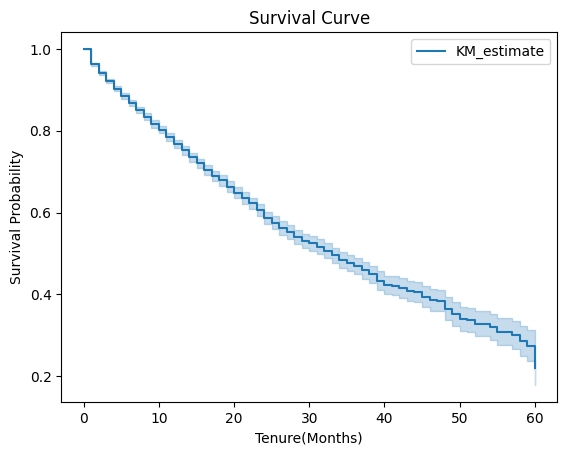

In [32]:
# Survival Analysis:
# To check how long customers stay
!pip install lifelines
from lifelines import KaplanMeierFitter # use of powerful python library for survival analysis
kmf=KaplanMeierFitter()

# Plot survival curve:
Tenure=df['TenureMonths']
E=df['Churned']
kmf.fit(Tenure,event_observed=E)
kmf.plot_survival_function()
plt.title("Survival Curve")
plt.xlabel("Tenure(Months)")
plt.ylabel("Survival Probability")
plt.savefig("survival_curve.png",bbox_inches="tight")
plt.show()



In [31]:
# saving important visualizations:
import os
os.makedirs("image",exist_ok=True)
plt.savefig("image/survival_curve.png",bbox_inches="tight")

<Figure size 640x480 with 0 Axes>